In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")

use = ["STABR","C_OUT_TY","LOCALE","CNTYPOP","SQ_FEET","HOURS","WKS_OPEN"]
df = pd.read_csv("pls_fy22_outlet_pud22i.csv", encoding="latin1", low_memory=False, usecols=use)
df.info()

# ---- Attribute Identification ----
attr = pd.DataFrame({
    "Attribute":   ["STABR","C_OUT_TY","LOCALE","CNTYPOP","SQ_FEET","HOURS","WKS_OPEN"],
    "Scale":       ["Nominal","Nominal","Ordinal","Ratio","Ratio","Ratio","Ratio"],
    "Data type":   ["Categorical","Categorical","Categorical (coded)","Discrete (count)","Continuous","Continuous","Discrete (count)"],
    "Suitable operations": ["Mode, counts, group-by","Mode, counts, group-by","Median, mode, rank-based tests",
                            "All statistics","All statistics","All statistics","All statistics"],
}).set_index("Attribute")
attr["Unique values"] = df[attr.index].nunique()
attr["Pandas dtype"]  = df[attr.index].dtypes.astype(str)
display(attr)
# Quality: negative codes (-1,-3,-4,-9) mean missing; LOCALE has stray 'M'
df["LOCALE"] = pd.to_numeric(df.LOCALE, errors="coerce")
df[["SQ_FEET","HOURS","WKS_OPEN"]] = df[["SQ_FEET","HOURS","WKS_OPEN"]].mask(lambda x: x < 0)
df["area"] = pd.cut(df.LOCALE, [0,19,29,39,49], labels=["City","Suburb","Town","Rural"])
print(df.isna().sum(), "| duplicates:", df.duplicated().sum())  # exact duplicate rows are expected in outlet-level data; inspect before dropping

# Buildings only (bookmobiles BS/BM have no SQ_FEET)
b = df[df.C_OUT_TY.isin(["CE","BR"])].dropna(subset=["area"]).copy()

# Median imputation within locale group (robust to skew)
for c in ["SQ_FEET","HOURS"]:
    b[c] = b[c].fillna(b.groupby("area", observed=True)[c].transform("median"))
b["WKS_OPEN"] = b.WKS_OPEN.fillna(b.WKS_OPEN.median())

# Derived + normalized
b["log_sqft"] = np.log1p(b.SQ_FEET)
b["underserved"] = b.HOURS < 1000                     # ~ under 20 hrs/week
b["size_band"] = pd.qcut(b.SQ_FEET, 4, labels=["Q1 small","Q2","Q3","Q4 large"])
from sklearn.preprocessing import MinMaxScaler
b[["sq_n","hrs_n","pop_n"]] = MinMaxScaler().fit_transform(b[["SQ_FEET","HOURS","CNTYPOP"]])
print(b.shape, f"| underserved: {b.underserved.mean():.1%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17546 entries, 0 to 17545
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   STABR     17546 non-null  object
 1   C_OUT_TY  17546 non-null  object
 2   SQ_FEET   17546 non-null  int64 
 3   HOURS     17546 non-null  int64 
 4   WKS_OPEN  17546 non-null  int64 
 5   CNTYPOP   17546 non-null  int64 
 6   LOCALE    17546 non-null  object
dtypes: int64(4), object(3)
memory usage: 959.7+ KB


,Scale,Data type,Suitable operations,Unique values,Pandas dtype
Attribute,,,,,
STABR,Nominal,Categorical,"Mode, counts, group-by",56,object
C_OUT_TY,Nominal,Categorical,"Mode, counts, group-by",4,object
LOCALE,Ordinal,Categorical (coded),"Median, mode, rank-based tests",13,object
CNTYPOP,Ratio,Discrete (count),All statistics,3069,int64
SQ_FEET,Ratio,Continuous,All statistics,6744,int64
HOURS,Ratio,Continuous,All statistics,2850,int64
WKS_OPEN,Ratio,Discrete (count),All statistics,56,int64


STABR         0
C_OUT_TY      0
SQ_FEET     899
HOURS       698
WKS_OPEN    609
CNTYPOP       0
LOCALE       13
area         13
dtype: int64 | duplicates: 281
(16870, 14) | underserved: 9.1%


In [ ]:
c = ["HOURS","SQ_FEET","CNTYPOP"]; x = b[c]
Q1, Q3 = x.quantile(.25), x.quantile(.75); IQR = Q3 - Q1
s = pd.DataFrame({"mean":x.mean(), "median":x.median(), "mode":x.mode().iloc[0],
  "geo_mean":x.apply(lambda v: stats.gmean(v[v>0])), "range":x.max()-x.min(),
  "var":x.var(), "std":x.std(), "RMSD":x.apply(lambda v: np.sqrt(((v-v.mean())**2).mean())),
  "coef_disp":x.std()/x.mean(), "skew":x.skew(), "kurtosis":x.kurt(),
  "pearson_skew":3*(x.mean()-x.median())/x.std(), "bowley":(Q3+Q1-2*x.median())/IQR,
  "n_outliers":((x<Q1-1.5*IQR)|(x>Q3+1.5*IQR)).sum()})
display(s.round(2).T)

# Weighted mean (hours weighted by county pop) + grouped-data mean of SQ_FEET
print("Weighted mean HOURS:", round(np.average(b.HOURS, weights=b.CNTYPOP), 1))
g = pd.cut(b.SQ_FEET, [0,1000,2500,5000,10000,50000,1e6]).value_counts().sort_index()
print("Grouped mean SQ_FEET:", round(sum(i.mid*n for i, n in g.items())/g.sum(), 1))

# Do locales differ? Do size/population relate to hours? (non-parametric: data is skewed)
print(b.groupby("area", observed=True).agg(n=("HOURS","size"), med_hours=("HOURS","median"),
      med_sqft=("SQ_FEET","median"), pct_underserved=("underserved","mean")).round(3))
print(stats.kruskal(*[v.HOURS for _, v in b.groupby("area", observed=True)]))
print(b[c].corr("spearman").round(2))

# Similarity between locale profiles (Euclidean distance on normalized means)
from scipy.spatial.distance import pdist, squareform
p = b.groupby("area", observed=True)[["sq_n","hrs_n","pop_n"]].mean()
print(pd.DataFrame(squareform(pdist(p)), index=p.index, columns=p.index).round(3))

,HOURS,SQ_FEET,CNTYPOP
mean,2106.02,1.288383e+04,6.213428e+05
median,2184.00,6.972500e+03,1.271890e+05
mode,2080.00,1.000000e+04,9.721138e+06
geo_mean,1922.90,6.581080e+03,1.347212e+05
range,8760.00,9.699700e+05,9.720905e+06
var,592314.83,6.595621e+08,1.985938e+12
std,769.62,2.568194e+04,1.409233e+06
RMSD,769.60,2.568118e+04,1.409191e+06
coef_disp,0.37,1.990000e+00,2.270000e+00
skew,-0.29,1.344000e+01,4.630000e+00


Weighted mean HOURS: 2333.8
Grouped mean SQ_FEET: 30504.0
           n  med_hours  med_sqft  pct_underserved
area                                              
City    2890     2418.0   13000.0            0.047
Suburb  4471     2600.0   12625.0            0.030
Town    3323     2288.0    8692.5            0.040
Rural   6186     1603.0    2800.0            0.183
KruskalResult(statistic=np.float64(5013.066675546034), pvalue=np.float64(0.0))
         HOURS  SQ_FEET  CNTYPOP
HOURS     1.00     0.69     0.37
SQ_FEET   0.69     1.00     0.44
CNTYPOP   0.37     0.44     1.00
area     City  Suburb   Town  Rural
area                               
City    0.000   0.051  0.148  0.175
Suburb  0.051   0.000  0.106  0.148
Town    0.148   0.106  0.000  0.072
Rural   0.175   0.148  0.072  0.000


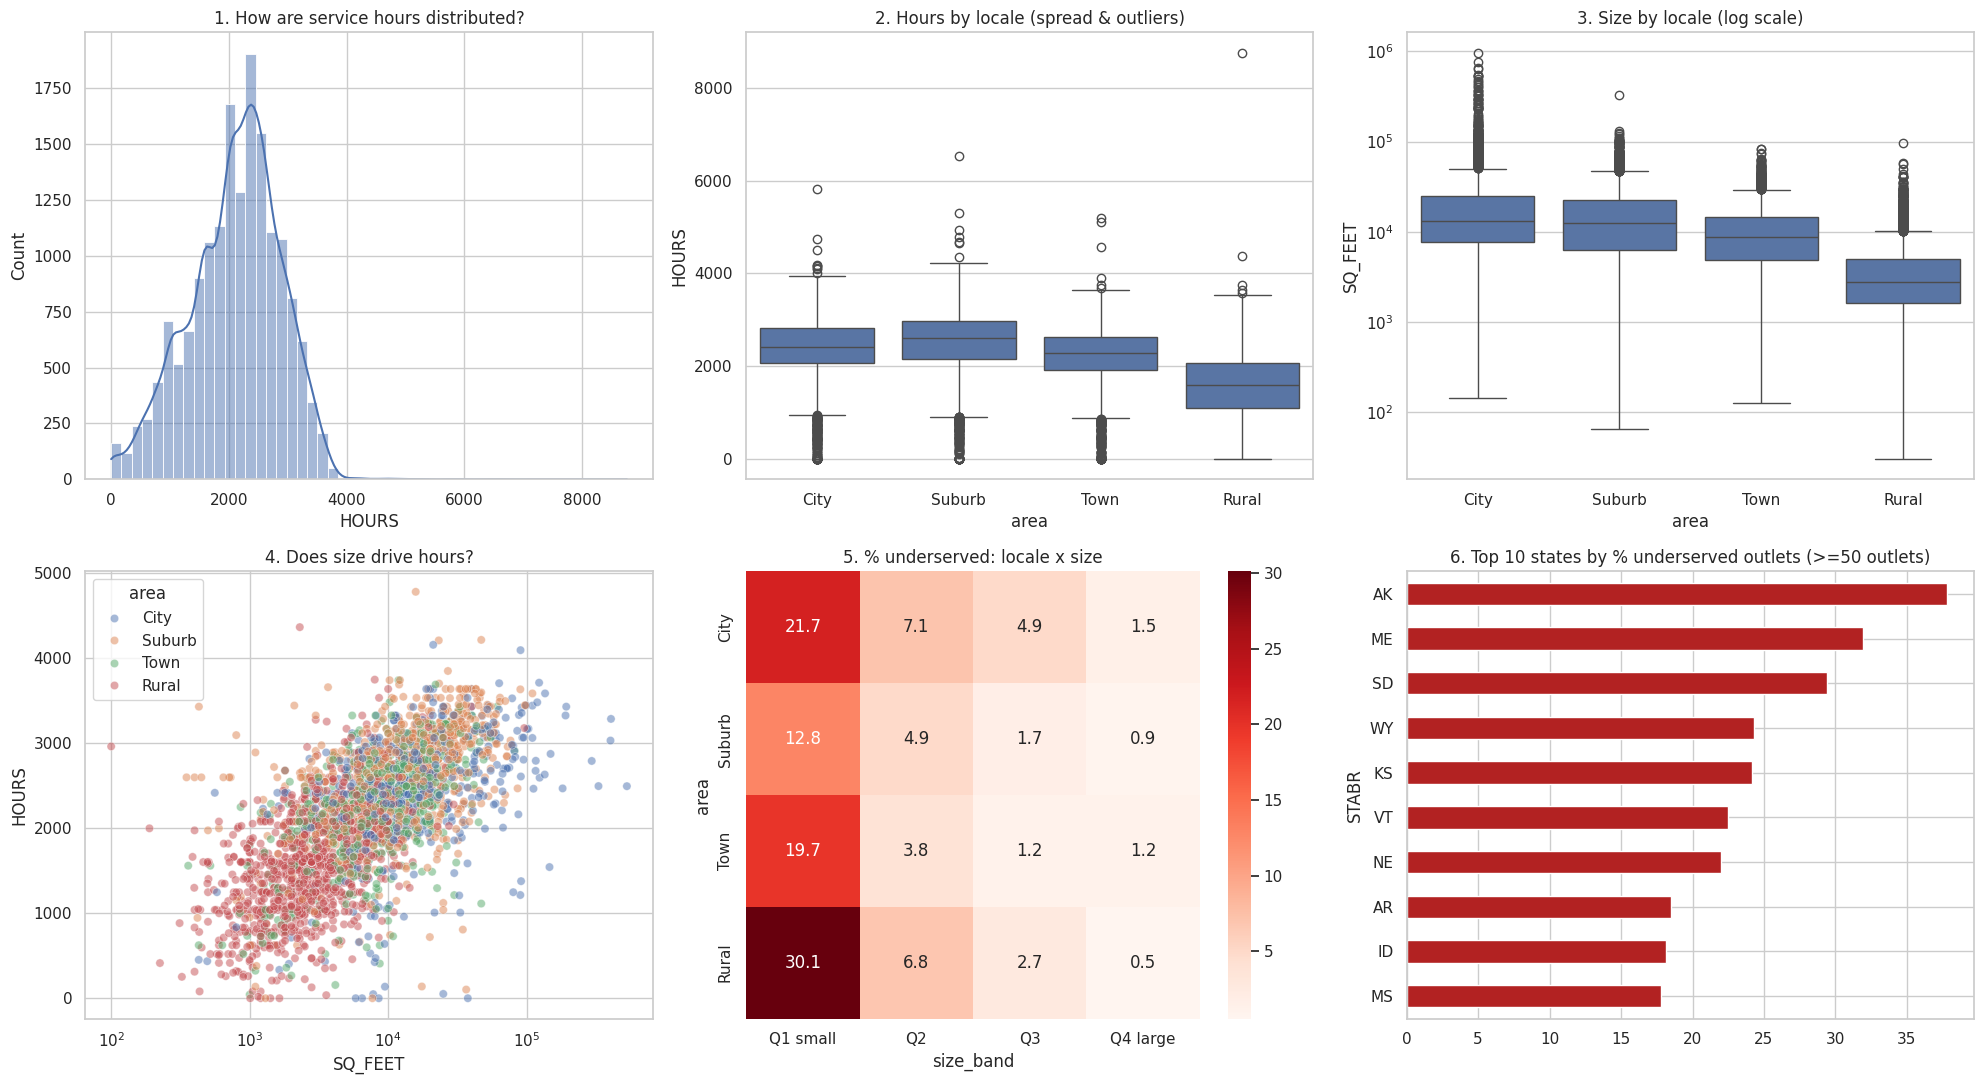

In [ ]:
st = b.groupby("STABR").agg(n=("HOURS","size"), pct=("underserved","mean")); st = st[st.n >= 50]

fig, ax = plt.subplots(2, 3, figsize=(20, 11))
sns.histplot(b.HOURS, bins=50, kde=True, ax=ax[0,0]).set_title("1. How are service hours distributed?")
sns.boxplot(data=b, x="area", y="HOURS", ax=ax[0,1]).set_title("2. Hours by locale (spread & outliers)")
sns.boxplot(data=b, x="area", y="SQ_FEET", ax=ax[0,2]).set(yscale="log", title="3. Size by locale (log scale)")
sns.scatterplot(data=b.sample(3000, random_state=1), x="SQ_FEET", y="HOURS", hue="area", alpha=.5, ax=ax[1,0]).set(xscale="log", title="4. Does size drive hours?")
sns.heatmap(b.pivot_table(index="area", columns="size_band", values="underserved", aggfunc="mean", observed=True)*100,
            annot=True, fmt=".1f", cmap="Reds", ax=ax[1,1]).set_title("5. % underserved: locale x size")
(st.pct.nlargest(10)*100).plot.barh(color="firebrick", ax=ax[1,2]).invert_yaxis()
ax[1,2].set_title("6. Top 10 states by % underserved outlets (>=50 outlets)")
plt.tight_layout(); plt.show()